# Fe-NTA active-space simulation

This notebook analyzes the ten-spin-orbital Fe-NTA workload with the released tensor data, exact references, and repeated number-preserving VQE runs.


In [5]:
import warnings
from math import pi
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import OptimizeWarning

import vqe_lab as vqe

ROOT = Path.cwd().resolve()
for _ in range(5):
    if (ROOT / "workloads").is_dir() and (ROOT / "pyproject.toml").is_file():
        break
    ROOT = ROOT.parent
else:
    raise RuntimeError("Could not find the project root.")

warnings.filterwarnings(
    "ignore",
    message="Unknown solver options: iprint",
    category=OptimizeWarning,
)

import os

SPIN_STATE = "LS"
DEFAULT_MOLECULE_DIR = (
    ROOT
    / "notebooks"
    / "fe_nta"
    / "Fe3_NTA_doublet_CASSCF"
)
MOLECULE_DIR = Path(os.environ.get("FE_NTA_DIR", DEFAULT_MOLECULE_DIR))
if not (MOLECULE_DIR / "data_file.json").is_file():
    raise RuntimeError(
        "Set FE_NTA_DIR to a Fe-NTA tensor-data directory, or restore the "
        "bundled Fe3_NTA_doublet_CASSCF directory."
    )

## Setup and exact reference

Exact ground state energy: -2149.30236612 Ha
Half-chain entanglement entropy: 0.53018593 bits


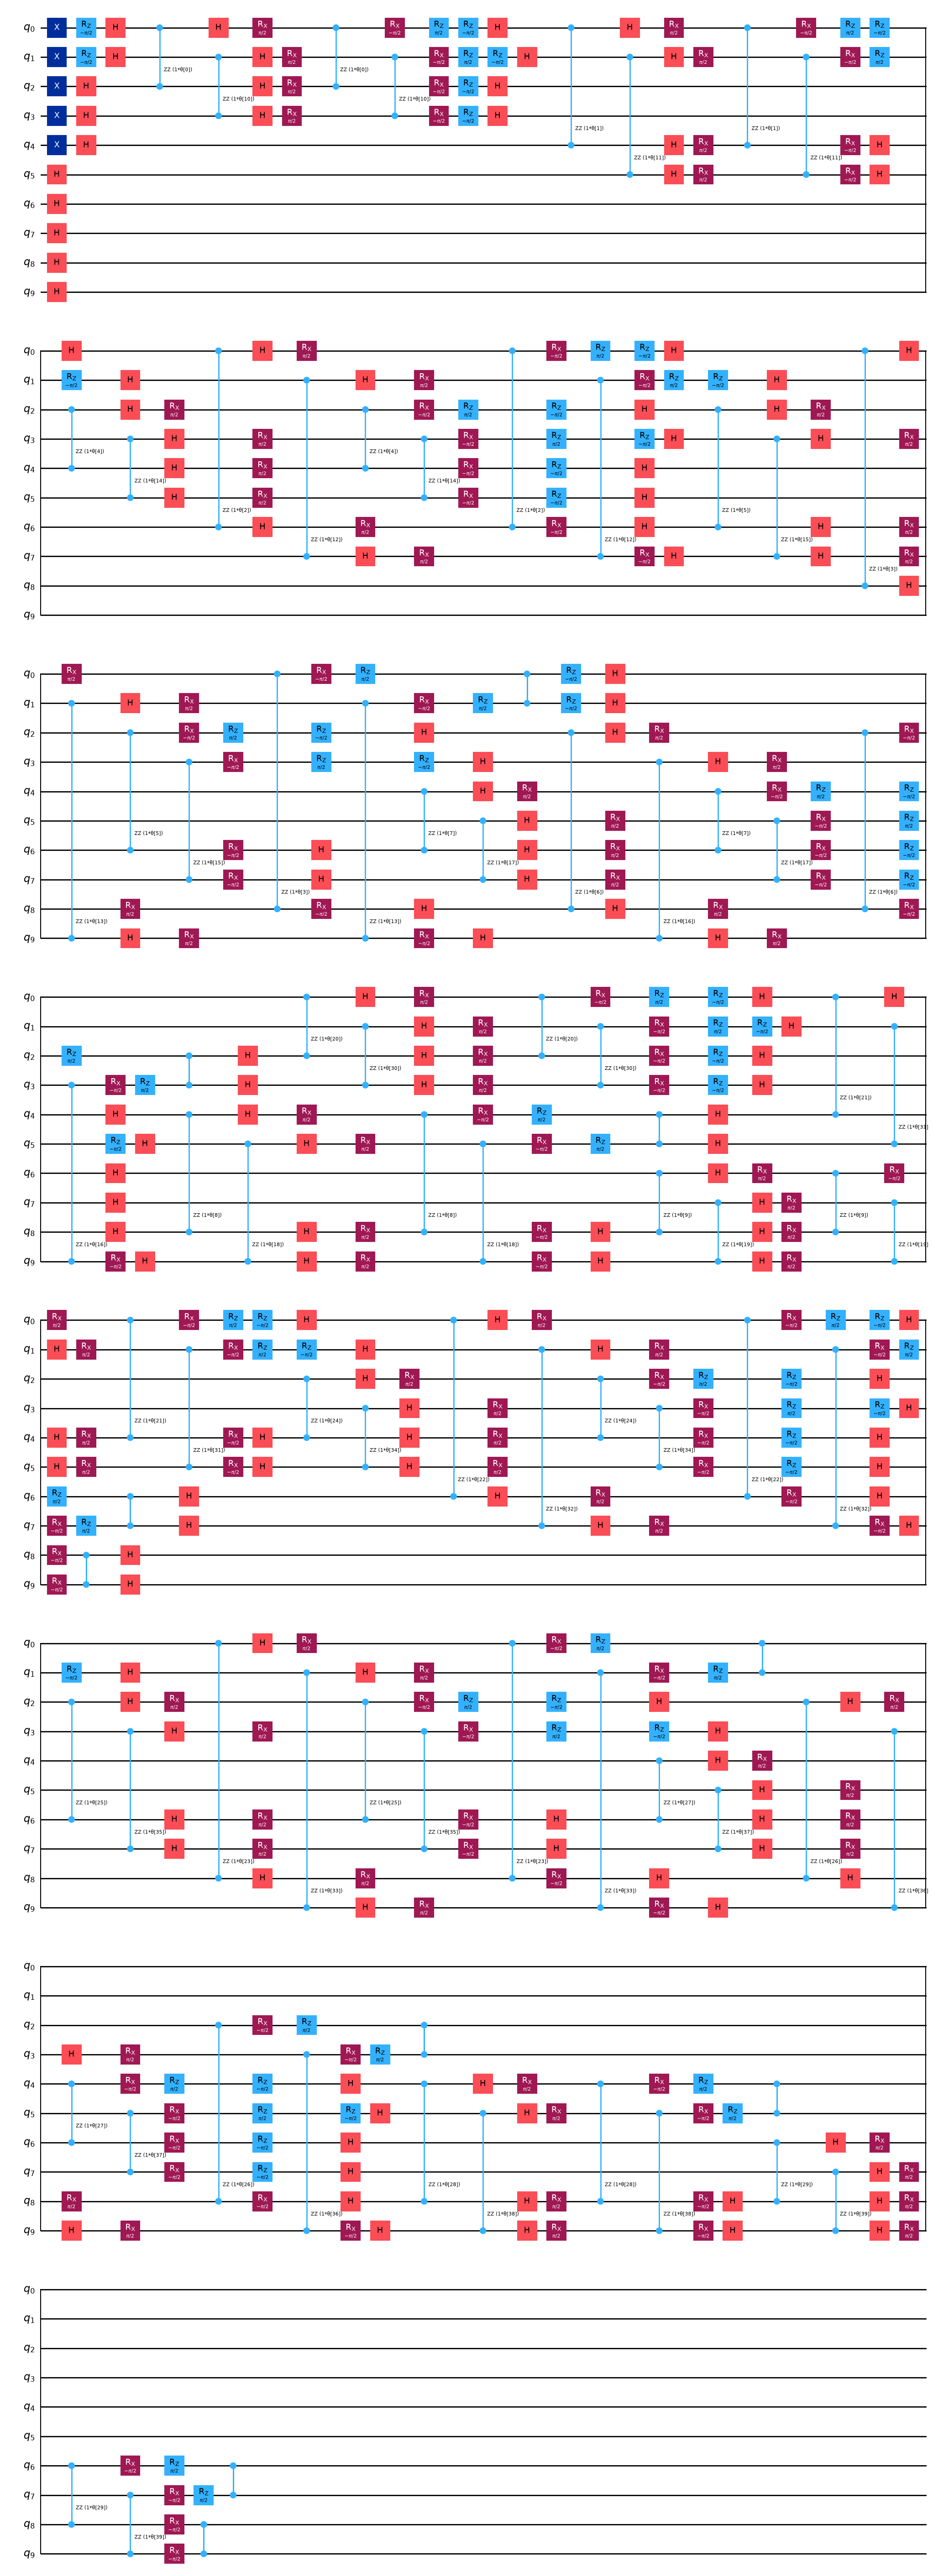

In [2]:
model = vqe.load_workload(ROOT / "workloads" / "fe_nta.py")
HAMILTONIAN = {"molecule_dir": MOLECULE_DIR, "spin_state": SPIN_STATE}
ANSATZ = {
    "num_qubits": 10,
    "num_electrons": 5,
    "reps": 2,
    "spin_state": SPIN_STATE,
    "parametric": True,
    "entanglement": "full",
}

base = vqe.Experiment(model, hamiltonian=HAMILTONIAN, ansatz=ANSATZ)
exact = base.exact(return_eigenvector=True)
exact_entropy = vqe.entropy(exact.eigenvector)

print(f"Exact ground state energy: {exact.energy:.8f} Ha")
print(f"Half-chain entanglement entropy: {exact_entropy:.8f} bits")
vqe.draw_ansatz(model.ansatz(**ANSATZ), fold=30)


## Parametric and fixed Givens ansätze
Both variants use two full-entanglement layers. Initial Givens angles are drawn from a small normal distribution around the Hartree-Fock reference, and L-BFGS-B is constrained to the physical angle interval. 

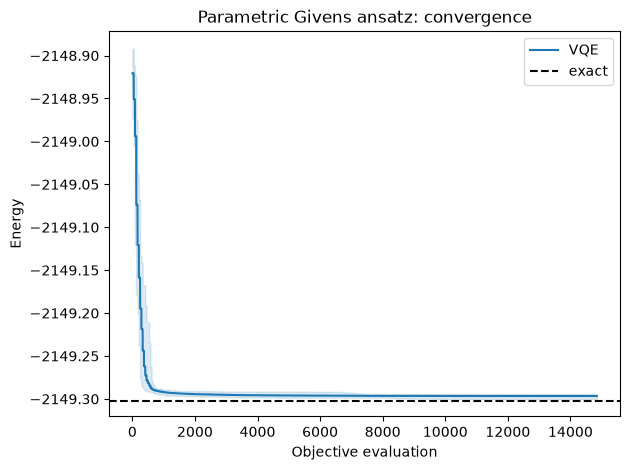

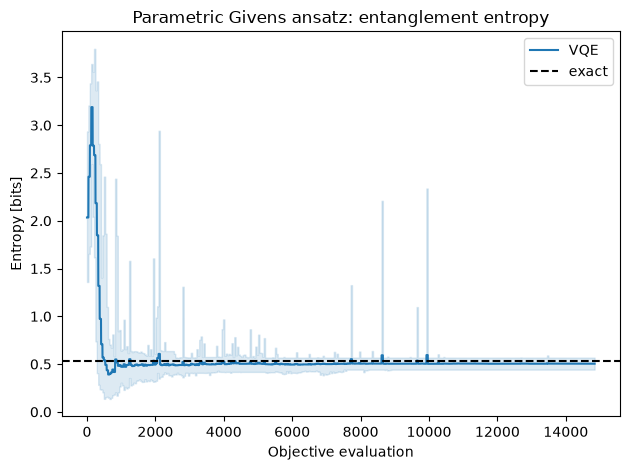

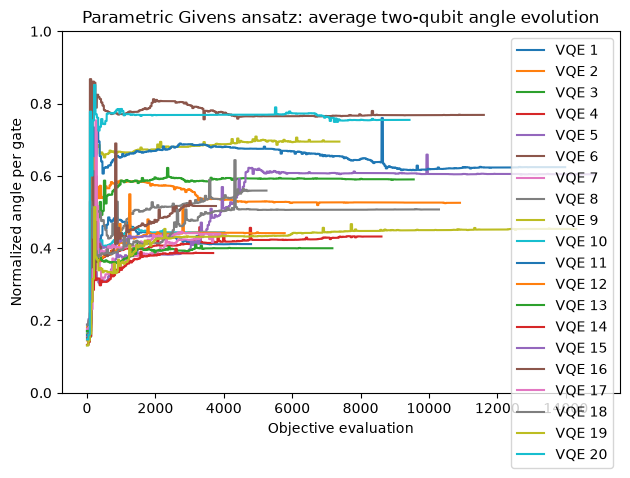

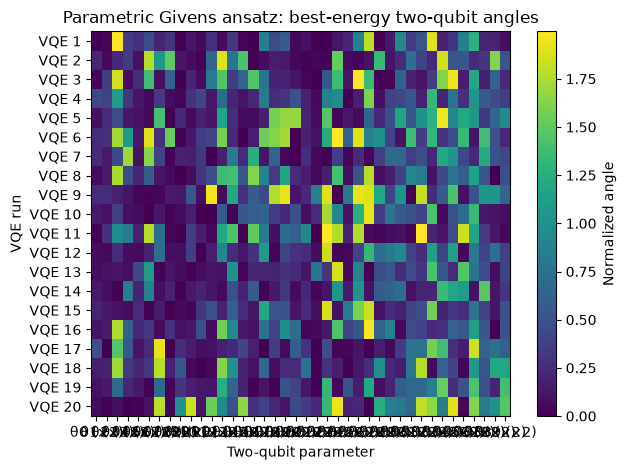

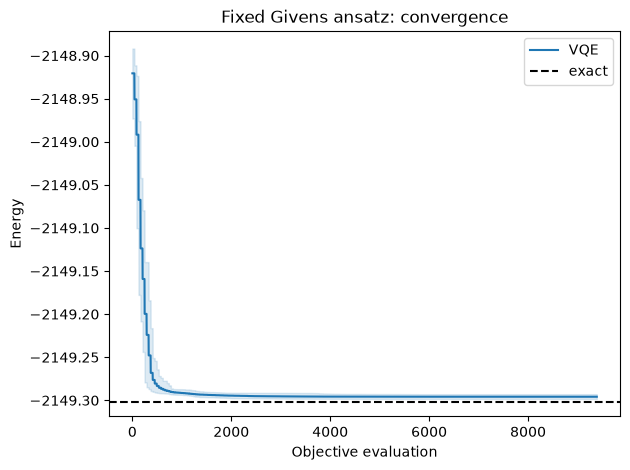

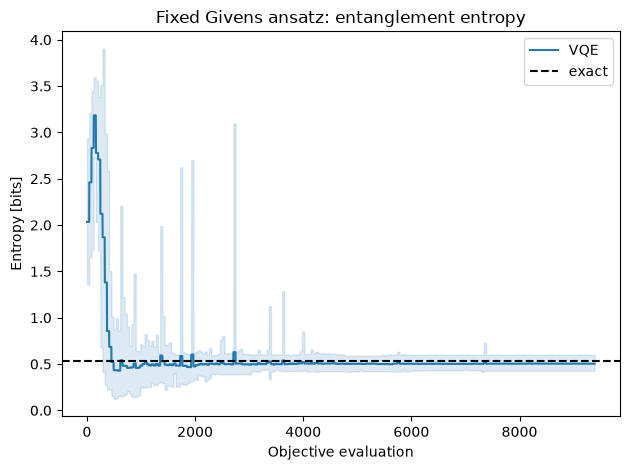

In [3]:
def fe_nta_initial_point(configuration, seed):
    """Generate a Hartree-Fock-near seeded Givens-angle vector."""

    circuit = model.ansatz(**configuration["ansatz"])
    point = np.random.default_rng(seed).normal(0.0, 0.15, circuit.num_parameters)
    return np.clip(point, -pi, pi)


VARIANTS = {"parametric": True, "fixed": False}
results_by_variant = {}
for variant, parametric in VARIANTS.items():
    ansatz = {**ANSATZ, "parametric": parametric}
    results = vqe.run_grid(
        model,
        hamiltonian=HAMILTONIAN,
        ansatz=ansatz,
        repeats=20,
        seed=97531,
        initial_point_factory=fe_nta_initial_point,
        optimizer="lbfgsb",
        maxiter=1000,
        optimizer_bounds=(-pi, pi),
    )
    assert not results.failures, results.failures
    results_by_variant[variant] = results

    vqe.plot_convergence(results.runs, exact=exact)
    plt.title(f"{variant.capitalize()} Givens ansatz: convergence")
    plt.show()

    vqe.plot_entropy(results.runs, exact=exact_entropy)
    plt.title(f"{variant.capitalize()} Givens ansatz: entanglement entropy")
    plt.show()

    if parametric:
        vqe.plot_parameters(results.runs, absolute=True)
        plt.title("Parametric Givens ansatz: average two-qubit angle evolution")
        plt.show()

        vqe.plot_parameters(results.runs, heatmap=True, absolute=True)
        plt.title("Parametric Givens ansatz: best-energy two-qubit angles")
        plt.show()


## Parametric versus fixed-entangler comparison

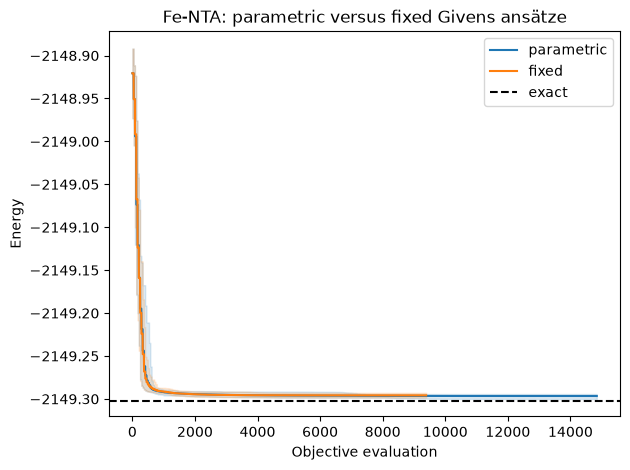

parametric: best energy error = 0.00230404 Ha
fixed: best energy error = 0.00393646 Ha


In [4]:
groups = [(label, results.runs) for label, results in results_by_variant.items()]
vqe.plot_convergence(groups, exact=exact)
plt.title("Fe-NTA: parametric versus fixed Givens ansätze")
plt.show()

for label, results in results_by_variant.items():
    best_error = min(run.energy for run in results.runs) - exact.energy
    print(f"{label}: best energy error = {best_error:.8f} Ha")
